# Unit 4 : Regression- Model Training & Evaluation

In [3]:
# --> Simple Liner Regression
# --> Multiple Liner Regression
# --> Polynoial Regression

In [6]:
# Evaluation Using ----
#                     --> R-Squared ( R^2 score )
#                     --> MAE ( Mean Absolute Error )
#                     --> MSE ( Mean Squared Error )

## Linear Regression

In [7]:
# --> statistical Method used to model the relationship between a dependent variable.
# --> The goal of LR is to find the best fiting line that describes the relationship between the variables.

In [10]:
# y=mx+c  --> m = E(x-x')(y-y') / E(x-x')^2
#         --> c = y(mean) - m*x(mean)
#         --> ypred = m*x + c
#         --> Error = y - ypred
#         --> MSE = (y-ypred)^2'
#         --> MAE = ABS(y-ypred)'

#
						
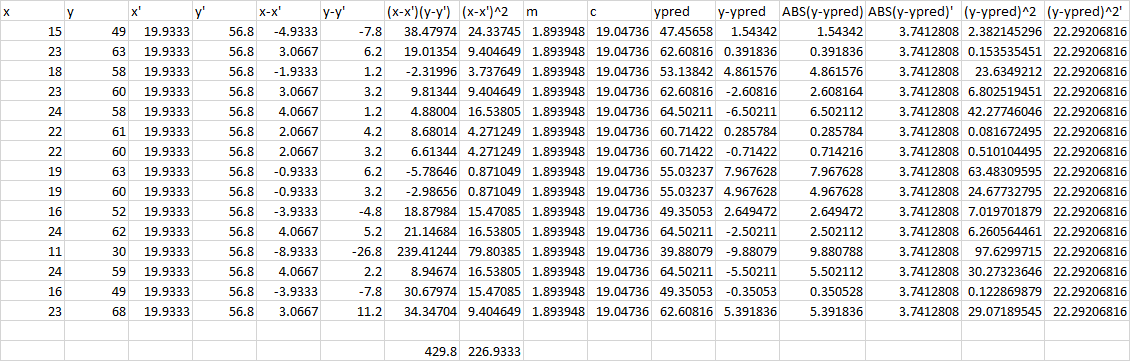

In [38]:
import pandas as pd
data=pd.read_csv("Test.csv")
df=pd.DataFrame(data)
df

,x,y
0,15,49
1,23,63
2,18,58
3,23,60
4,24,58
5,22,61
6,22,60
7,19,63
8,19,60
9,16,52


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   x       15 non-null     int64
 1   y       15 non-null     int64
dtypes: int64(2)
memory usage: 372.0 bytes


In [40]:
df.isna().sum()

x    0
y    0
dtype: int64

In [41]:
x=df.iloc[:,0:1]
y=df.iloc[:,-1]
print(type(x)) # DataFrame
print(type(y)) # Series
print(x)
print("-"*50)
print(y)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
     x
0   15
1   23
2   18
3   23
4   24
5   22
6   22
7   19
8   19
9   16
10  24
11  11
12  24
13  16
14  23
--------------------------------------------------
0     49
1     63
2     58
3     60
4     58
5     61
6     60
7     63
8     60
9     52
10    62
11    30
12    59
13    49
14    68
Name: y, dtype: int64


In [42]:
print(x.shape) # DataFrame should be in 2 dimention
print(y.shape) # Series should be in 1 dimention

(15, 1)
(15,)


In [72]:
# If you don't convert in traing and testing
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x,y)
y_pred=lr.predict(x)
print(y_pred)

[47.45652174 62.60810811 53.13836663 62.60810811 64.5020564  60.71415981
 60.71415981 55.03231492 55.03231492 49.35047004 64.5020564  39.88072855
 64.5020564  49.35047004 62.60810811]


In [64]:
print("Coefficient :",lr.coef_)
print("Intercept : ",lr.intercept_)

Coefficient : [1.8939483]
Intercept :  19.047297297297284


In [46]:
# If you convert in traing and testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(13, 1)
(13,)
(2, 1)
(2,)


In [47]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
print(y_pred)

[62.41322902 54.56827881]


In [48]:
print(x_test)
print("-"*50)
print(y_test)

    x
3  23
7  19
--------------------------------------------------
3    60
7    63
Name: y, dtype: int64


In [49]:
diff=pd.DataFrame({'Acual':y_test,'Predicted':y_pred})
diff

,Acual,Predicted
3,60,62.413229
7,63,54.568279


In [50]:
print("Coefficient :",lr.coef_)
print("Intercept : ",lr.intercept_)

Coefficient : [1.96123755]
Intercept :  17.30476529160739


In [67]:
# This is run After [64] not [50] otherwise give error

from sklearn import metrics
print("MAE : ",metrics.mean_absolute_error(y,y_pred))
print("MSE : ",metrics.mean_squared_error(y,y_pred))

MAE :  3.7412847630238946
MSE :  22.292068155111636


In [68]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
print("MAE : ",mean_absolute_error(y,y_pred))
print("MSE : ",mean_squared_error(y,y_pred))

MAE :  3.7412847630238946
MSE :  22.292068155111636


In [71]:
# If you don't convert in traing and testing
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x,y)
y_pred=lr.predict([[18]])
print(y_pred)

[53.13836663]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [73]:
print("R2 Score :",metrics.r2_score(y,y_pred))

R2 Score : 0.7088287858527738


In [1]:
# Actual   Pred
#  80       78
#  70       72
#  90       85

# mean y = (80+70+90)/3
#        = 80

# R^2 = 1 - (ss_res/ss_total)   (ss=sum of squre)
# ss_total = (80-80)^2+(70-80)^2+(90-80)^2=200
# ss_res = (80-78)^2 + (70-72)^2 + (90-85)^2 = 33
# R^2 = 1 - (33/200) = 0.835

In [11]:
import pandas as pd
data={"Hours_stadied":[1,2,3,4,5,6,7],
     "Exam_score":[50,55,65,70,75,80,85]}
df=pd.DataFrame(data)
# either like this because both's shape are same
# x=np.array([[1],[2],[3],[4],[5],[6],[7]])
# y=np.array([50,55,65,70,75,80,85])

x=df.iloc[:,0:1] # or
# x=df[["Hours_stadied"]]
x

,Hours_stadied
0,1
1,2
2,3
3,4
4,5
5,6
6,7


In [12]:
y=df.iloc[:,-1] # or
# y=df["Exam_score"]
y

0    50
1    55
2    65
3    70
4    75
5    80
6    85
Name: Exam_score, dtype: int64

In [16]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x,y)
y_pred=lr.predict(x)
diff=pd.DataFrame({"Acual":y,"Predict":y_pred})
diff

,Acual,Predict
0,50,50.892857
1,55,56.785714
2,65,62.678571
3,70,68.571429
4,75,74.464286
5,80,80.357143
6,85,86.250000


In [23]:
from sklearn.metrics import *
print("MAE : ",mean_absolute_error(y,y_pred))
print("MSE : ",mean_squared_error(y,y_pred))
print("R2 Score :",r2_score(y,y_pred))

MAE :  1.2244897959183672
MSE :  1.9132653061224514
R2 Score : 0.9864130434782609


In [25]:
from sklearn import metrics
print("MAE : ",metrics.mean_absolute_error(y,y_pred))
print("MSE : ",metrics.mean_squared_error(y,y_pred))
print("R2 Score :",metrics.r2_score(y,y_pred))

MAE :  1.2244897959183672
MSE :  1.9132653061224514
R2 Score : 0.9864130434782609


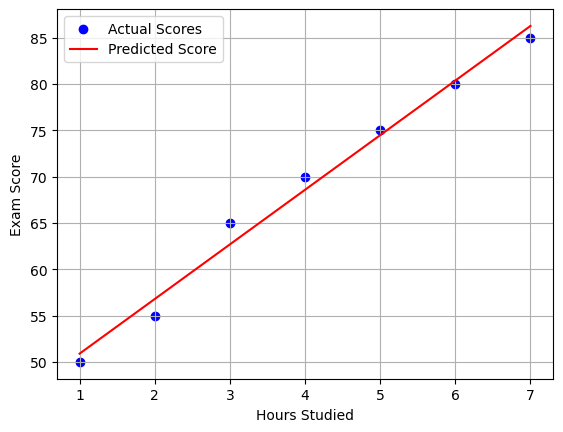

In [27]:
import matplotlib.pyplot as plt
plt.scatter(x,y,color='blue',label='Actual Scores')
plt.plot(x,y_pred,color='red',label='Predicted Score')
plt.xlabel('Hours Studied')
plt.ylabel("Exam Score")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
import pandas as pd
df=pd.read_csv("Book1.csv")
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [48]:
x=df.iloc[:,0:1]
y=df.iloc[:,-1]
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [49]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(180, 1)
(180,)
(20, 1)
(20,)


In [50]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
print(y_pred)

[2.95599947 4.35419203 3.19471527 1.93861546 3.50163559 3.35954285
 2.79117189 2.96736689 3.08672479 3.93928123 3.57552382 2.96736689
 2.77980448 2.67181399 3.67214688 3.22881753 3.97338349 2.92758092
 2.22848465 3.31975689]


In [51]:
print(x_test)
print("-"*50)
print(y_test)

     cgpa
58   6.92
40   9.38
34   7.34
102  5.13
184  7.88
198  7.63
95   6.63
4    6.94
29   7.15
168  8.65
171  8.01
18   6.94
11   6.61
89   6.42
110  8.18
118  7.40
159  8.71
35   6.87
136  5.64
59   7.56
--------------------------------------------------
58     3.09
40     4.02
34     3.42
102    1.37
184    3.14
198    3.96
95     2.79
4      3.57
29     3.49
168    3.52
171    3.76
18     2.98
11     2.60
89     2.72
110    3.76
118    2.88
159    4.08
35     2.87
136    2.10
59     3.31
Name: package, dtype: float64


In [52]:
diff=pd.DataFrame({'Acual':y_test,'Predicted':y_pred})
diff

,Acual,Predicted
58,3.09,2.955999
40,4.02,4.354192
34,3.42,3.194715
102,1.37,1.938615
184,3.14,3.501636
198,3.96,3.359543
95,2.79,2.791172
4,3.57,2.967367
29,3.49,3.086725
168,3.52,3.939281


In [53]:
from sklearn import metrics
print("MAE : ",metrics.mean_absolute_error(y_test,y_pred))
print("MSE : ",metrics.mean_squared_error(y_test,y_pred))
print("R2 Score :",metrics.r2_score(y_test,y_pred))

MAE :  0.2407378157739672
MSE :  0.09630812755183496
R2 Score : 0.7763411228752372


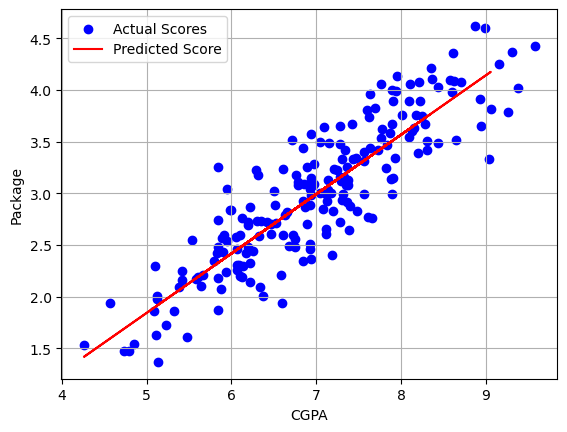

In [64]:
import matplotlib.pyplot as plt
plt.scatter(x,y,color='blue',label='Actual Scores')
plt.plot(x_test,y_pred,color='red',label='Predicted Score')
plt.xlabel('CGPA')
plt.ylabel("Package")
plt.legend()
plt.grid(True)
plt.show()

In [58]:
from sklearn.model_selection import train_test_split
from sklearn import metrics

min1=1000
st=0
abso=0
for i in range(1,43):
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=i)
    
    lr=LinearRegression()
    lr.fit(x_train,y_train)
    y_pred=lr.predict(x_test)
    abso=metrics.mean_absolute_error(y_test, y_pred)

    if(abso<min1):
        min1=abso
        st=i
        
print(st)
print(min1)

19
0.18405380979816172


<Axes: xlabel='cgpa', ylabel='package'>

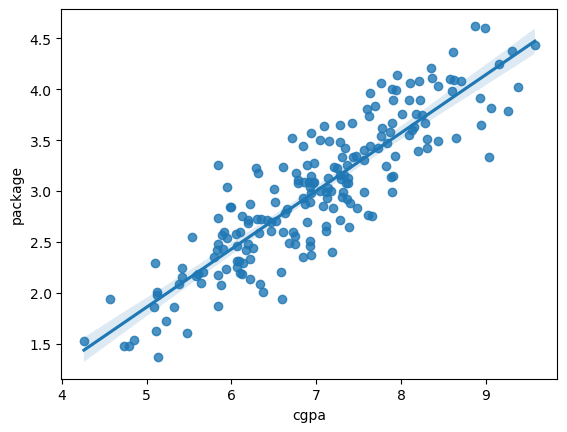

In [59]:
import seaborn as sns
sns.regplot(data=df,x='cgpa',y='package')

In [66]:
y_pred=lr.predict([[6.5]]) # for speciphic cgpa to find package
print(y_pred)

[2.70566014]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [67]:
y_pred=lr.predict([[8.5]]) # for speciphic cgpa to find package
print(y_pred)

[3.85417308]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
df=pd.read_csv("car data.csv")
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [2]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [3]:
df.drop(columns="Car_Name",inplace=True) # or
# df.drop("Car_Name",axis=1,inplace=True)
df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [4]:
df["age"]=2026-df['Year']
df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,age
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [5]:
df.drop("Year",axis=1,inplace=True)
df

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [6]:
df.columns

Index(['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner', 'age'],
      dtype='object')

In [7]:
df=pd.get_dummies(data=df,drop_first=True)
df

,Selling_Price,Present_Price,Kms_Driven,Owner,age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,0,10,True,False,False,True
297,4.00,5.90,60000,0,11,False,True,False,True
298,3.35,11.00,87934,0,17,False,True,False,True
299,11.50,12.50,9000,0,9,True,False,False,True


In [16]:
y=df["Selling_Price"]
# x=df[["Present_Price","Kms_Driven","Fuel_Type_Diesel","Fuel_Type_Petrol","Seller_Type_Individual","Transmission_Manual","Owner","age"]]
# x=df.iloc[:,1:]
x=df.drop("Selling_Price",axis=1)
x

,Present_Price,Kms_Driven,Owner,age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,5.59,27000,0,12,False,True,False,True
1,9.54,43000,0,13,True,False,False,True
2,9.85,6900,0,9,False,True,False,True
3,4.15,5200,0,15,False,True,False,True
4,6.87,42450,0,12,True,False,False,True
...,...,...,...,...,...,...,...,...
296,11.60,33988,0,10,True,False,False,True
297,5.90,60000,0,11,False,True,False,True
298,11.00,87934,0,17,False,True,False,True
299,12.50,9000,0,9,True,False,False,True


In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(270, 8)
(270,)
(31, 8)
(31,)


In [18]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
print(y_pred)

[ 7.81571082  2.97397349 -0.51868592  4.1824677   0.52531398  5.78936015
  1.94468562  2.59149653  7.7266758   0.98549534  8.10049466  3.51673114
  4.88719327  4.60739441 -2.0797094   3.09417821  7.95244807  6.7558933
  6.89442966  7.98707163  4.31991767  4.07318399 11.38026446  8.05346588
  9.60944582  3.45853307  3.87217962  1.07104394 -0.57093739 -0.55817872
  0.03214186]


In [19]:
diff=pd.DataFrame({'Acual':y_test,'Predicted':y_pred})
diff

,Acual,Predicted
285,7.40,7.815711
248,4.00,2.973973
150,0.50,-0.518686
217,3.15,4.182468
107,1.25,0.525314
206,5.75,5.789360
132,0.75,1.944686
73,2.65,2.591497
288,8.40,7.726676
157,0.48,0.985495


In [20]:
from sklearn import metrics
print("MAE : ",metrics.mean_absolute_error(y_test,y_pred))
print("MSE : ",metrics.mean_squared_error(y_test,y_pred))
print("R2 Score :",metrics.r2_score(y_test,y_pred))

MAE :  1.1782028069641932
MSE :  3.819256570893076
R2 Score : 0.47306784471590835


In [21]:
print("Coefficient :",lr.coef_)
print("Intercept : ",lr.intercept_)

Coefficient : [ 4.41970866e-01 -5.77059476e-06  3.16795662e-01 -3.99023445e-01
  2.24533333e+00  4.98314766e-01 -1.16510875e+00 -1.83476215e+00]
Intercept :  7.637777527722247


In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(240, 8)
(240,)
(61, 8)
(61,)


In [23]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
print(y_pred)

[ 7.86273200e+00  2.96828691e+00 -5.90305107e-01  4.21335952e+00
  4.83175534e-01  5.82053813e+00  1.95679784e+00  2.55809661e+00
  7.70870833e+00  9.78692192e-01  8.13484343e+00  3.51207180e+00
  4.90669281e+00  4.63905587e+00 -2.15886643e+00  3.13874624e+00
  7.98256903e+00  6.75937638e+00  6.90426580e+00  8.01440587e+00
  4.31168610e+00  4.00336757e+00  1.13040883e+01  8.07939189e+00
  9.54399823e+00  3.52133877e+00  3.80609808e+00  1.06074722e+00
 -6.01732475e-01 -6.19712043e-01  1.32818516e-03 -1.28500691e+00
  4.28533553e+00  2.06769487e+01  1.87563232e+01  4.27292100e+00
  3.48602852e+00  1.66739677e+00 -4.38707073e-02  5.78536030e+00
  8.03940428e+00  9.88367483e+00  4.09684249e-01  6.07997517e+00
  5.88038915e+00  4.32745252e+00  7.37534505e+00  5.86171335e+00
  8.21129880e+00  1.65455816e+00  3.83033706e+00  1.75047060e+00
  2.51406796e+00  4.20404709e+00  1.48991546e+00 -3.44185843e+00
  2.04806215e+01  6.62503544e-01  5.40027412e+00  5.65856241e+00
  6.47876234e-01]


In [24]:
diff=pd.DataFrame({'Acual':y_test,'Predicted':y_pred})
diff

,Acual,Predicted
285,7.40,7.862732
248,4.00,2.968287
150,0.50,-0.590305
217,3.15,4.213360
107,1.25,0.483176
...,...,...
62,18.75,20.480622
154,0.50,0.662504
218,6.45,5.400274
286,5.65,5.658562


In [25]:
from sklearn import metrics
print("MAE : ",metrics.mean_absolute_error(y_test,y_pred))
print("MSE : ",metrics.mean_squared_error(y_test,y_pred))
print("R2 Score :",metrics.r2_score(y_test,y_pred))

MAE :  1.0998575552990955
MSE :  2.9823848618597513
R2 Score : 0.8625260513315252


In [26]:
print("Coefficient :",lr.coef_)
print("Intercept : ",lr.intercept_)

Coefficient : [ 4.37233976e-01 -5.30613944e-06  3.45912849e-01 -4.13270098e-01
  2.23050770e+00  4.58549217e-01 -1.20927814e+00 -1.87014327e+00]
Intercept :  7.900300130264206


In [12]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn import metrics  

df = pd.read_csv("advertising.csv")


x = df.iloc[:, 1:4]
y=df["Sales"]

lr = LinearRegression()
lr.fit(x, y)

ypre = lr.predict(x)

diff = pd.DataFrame({
    'Actual': y,
    'Predicted': ypre,
    'Difference': y - ypre
})
print(diff)
print("MAE : ", metrics.mean_absolute_error(y, ypre))
print("MSE : ", metrics.mean_squared_error(y, ypre))  # It is worung

     Actual  Predicted  Difference
0      22.1  20.523974    1.576026
1      10.4  12.337855   -1.937855
2       9.3  12.307671   -3.007671
3      18.5  17.597830    0.902170
4      12.9  13.188672   -0.288672
..      ...        ...         ...
195     7.6   5.370342    2.229658
196     9.7   8.165312    1.534688
197    12.8  12.785921    0.014079
198    25.5  23.767321    1.732679
199    13.4  15.173196   -1.773196

[200 rows x 3 columns]
MAE :  1.2520112296870685
MSE :  2.784126314510936


In [20]:
import pandas as pd
df = pd.read_csv("FuelConsumptionCo2.csv")
df

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


In [21]:
df.drop(columns=["MAKE","MODEL","VEHICLECLASS","TRANSMISSION"],axis=1,inplace=True)
df

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,2.0,4,Z,9.9,6.7,8.5,33,196
1,2014,2.4,4,Z,11.2,7.7,9.6,29,221
2,2014,1.5,4,Z,6.0,5.8,5.9,48,136
3,2014,3.5,6,Z,12.7,9.1,11.1,25,255
4,2014,3.5,6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...
1062,2014,3.0,6,X,13.4,9.8,11.8,24,271
1063,2014,3.2,6,X,13.2,9.5,11.5,25,264
1064,2014,3.0,6,X,13.4,9.8,11.8,24,271
1065,2014,3.2,6,X,12.9,9.3,11.3,25,260


In [25]:
df.corr(numeric_only=True) # half Baki

,sno,Temperature,Pressure
sno,1.000000,1.000000,0.830873
Temperature,1.000000,1.000000,0.830873
Pressure,0.830873,0.830873,1.000000


# Poly Linear Regression

In [3]:
import pandas as pd
df=pd.read_csv("polylinearregression.csv")
df

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900
5,6,100,0.2700


In [4]:
from sklearn.linear_model import LinearRegression
x=df.iloc[:,0:1]
y=df.iloc[:,-1]
lr=LinearRegression()
lr.fit(x,y)
y_pred=lr.predict(x)
print(y_pred)

[-0.05086667 -0.00402667  0.04281333  0.08965333  0.13649333  0.18333333]


In [5]:
print("Coefficient :",lr.coef_)
print("Intercept : ",lr.intercept_)

Coefficient : [0.04684]
Intercept :  -0.09770666666666669


In [6]:
from sklearn import metrics
print("MAE : ",metrics.mean_absolute_error(y,y_pred))
print("MSE : ",metrics.mean_squared_error(y,y_pred))
print("R2 Score :",metrics.r2_score(y,y_pred))

MAE :  0.04765333333333333
MSE :  0.0028702675555555552
R2 Score : 0.6903499726039812


C:\Users\LJENG\AppData\Local\Temp\ipykernel_16048\1903322715.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


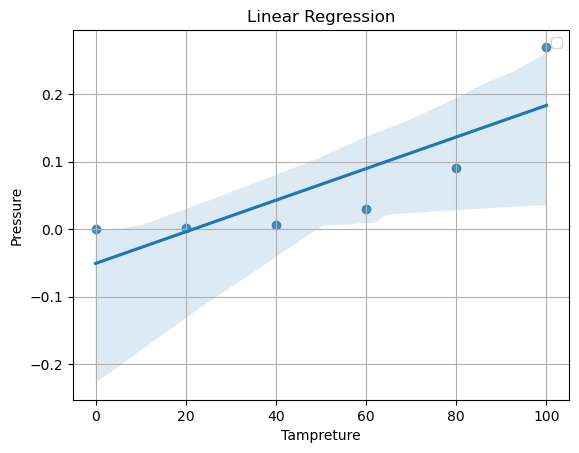

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.regplot(data=df,x="Temperature",y="Pressure")

plt.xlabel("Tampreture")
plt.ylabel("Pressure")

plt.title("Linear Regression")

plt.legend()
plt.grid(True)
plt.show()

In [24]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3)
x_poly=poly.fit_transform(x)
print(x_poly) # x^0 x^1 x^2 x^3

[[  1.   1.   1.   1.]
 [  1.   2.   4.   8.]
 [  1.   3.   9.  27.]
 [  1.   4.  16.  64.]
 [  1.   5.  25. 125.]
 [  1.   6.  36. 216.]]


In [25]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(x_poly,y)
y_pred=lr.predict(x_poly)
y_pred

array([-0.00198889,  0.00724444,  0.00371111,  0.02248889,  0.09865556,
        0.26728889])

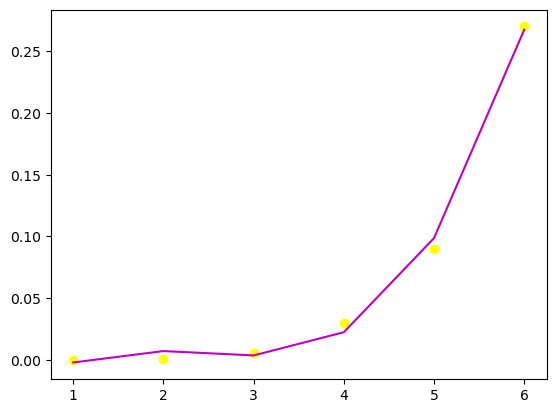

In [26]:
import matplotlib.pyplot as plt
plt.scatter(x,y,color="yellow")
plt.plot(x,y_pred,color="m")
plt.show()

In [27]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(x)
print(x_poly)

[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]
 [ 1.  5. 25.]
 [ 1.  6. 36.]]


In [28]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(x_poly,y)
y_pred=lr.predict(x_poly)
y_pred

array([ 0.01555, -0.01731, -0.01032,  0.03652,  0.12321,  0.24975])

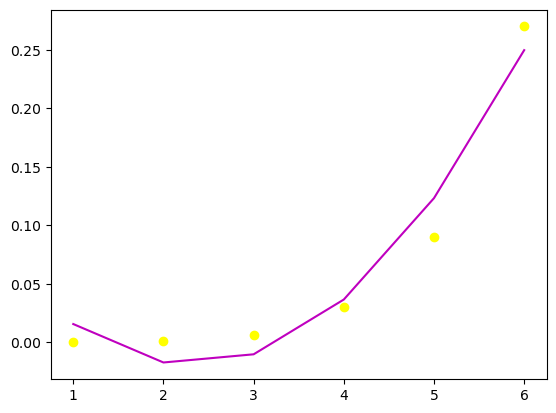

In [29]:
import matplotlib.pyplot as plt
plt.scatter(x,y,color="yellow")
plt.plot(x,y_pred,color="m")
plt.show()

In [30]:
import pandas as pd
df=pd.read_csv("car_data.csv")
df

,Horsepower,Weight,MPG
0,130,3504,18
1,165,3693,15
2,150,3436,18
3,140,3433,16
4,198,4341,14
5,220,4354,12
6,95,2372,25
7,88,2130,27
8,98,2228,24


In [35]:
from sklearn.linear_model import LinearRegression
x=df.iloc[:,:-1]
y=df.iloc[:,-1]
x

,Horsepower,Weight
0,130,3504
1,165,3693
2,150,3436
3,140,3433
4,198,4341
5,220,4354
6,95,2372
7,88,2130
8,98,2228


In [36]:
y

0    18
1    15
2    18
3    16
4    14
5    12
6    25
7    27
8    24
Name: MPG, dtype: int64

In [52]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(x)
print(x_poly)

[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]
 [ 1.  5. 25.]]


In [53]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(x_poly,y)
y_pred=lr.predict(x_poly)
y_pred

array([ 1.,  4.,  9., 16., 25.])

In [42]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(x)
print(x_poly)

[[1.0000000e+00 1.3000000e+02 3.5040000e+03 1.6900000e+04 4.5552000e+05
  1.2278016e+07]
 [1.0000000e+00 1.6500000e+02 3.6930000e+03 2.7225000e+04 6.0934500e+05
  1.3638249e+07]
 [1.0000000e+00 1.5000000e+02 3.4360000e+03 2.2500000e+04 5.1540000e+05
  1.1806096e+07]
 [1.0000000e+00 1.4000000e+02 3.4330000e+03 1.9600000e+04 4.8062000e+05
  1.1785489e+07]
 [1.0000000e+00 1.9800000e+02 4.3410000e+03 3.9204000e+04 8.5951800e+05
  1.8844281e+07]
 [1.0000000e+00 2.2000000e+02 4.3540000e+03 4.8400000e+04 9.5788000e+05
  1.8957316e+07]
 [1.0000000e+00 9.5000000e+01 2.3720000e+03 9.0250000e+03 2.2534000e+05
  5.6263840e+06]
 [1.0000000e+00 8.8000000e+01 2.1300000e+03 7.7440000e+03 1.8744000e+05
  4.5369000e+06]
 [1.0000000e+00 9.8000000e+01 2.2280000e+03 9.6040000e+03 2.1834400e+05
  4.9639840e+06]]


In [43]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_poly,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(7, 6)
(7,)
(2, 6)
(2,)


In [44]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
y_pred

array([25.53716178, 15.7560762 ])

In [46]:
import pandas as pd
x=[1,2,3,4,5]
y=[1,4,9,16,25]
x=pd.DataFrame(x)
y=pd.Series(y)
x

,0
0,1
1,2
2,3
3,4
4,5


In [47]:
y

0     1
1     4
2     9
3    16
4    25
dtype: int64

In [48]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(x)
print(x_poly)

[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]
 [ 1.  5. 25.]]


In [61]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(x_poly,y)
y_pred=lr.predict(x_poly)
y_pred

array([  1.,   8.,  27.,  64., 125.])

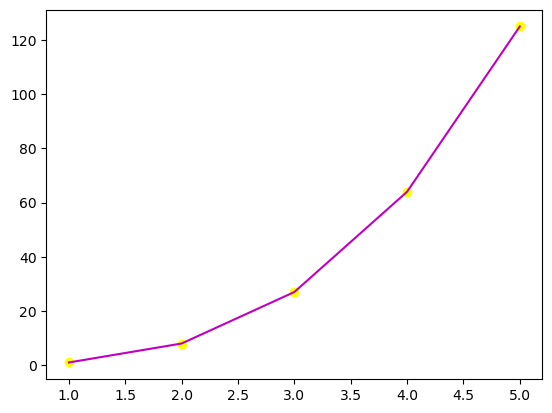

In [62]:
import matplotlib.pyplot as plt
plt.scatter(x,y,color="yellow")
plt.plot(x,y_pred,color="m")
plt.show()

In [55]:
import pandas as pd
x=[1,2,3,4,5]
y=[1,8,27,64,125]
x=pd.DataFrame(x)
y=pd.Series(y)
x

,0
0,1
1,2
2,3
3,4
4,5


In [56]:
y

0      1
1      8
2     27
3     64
4    125
dtype: int64

In [57]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3)
x_poly=poly.fit_transform(x)
print(x_poly)

[[  1.   1.   1.   1.]
 [  1.   2.   4.   8.]
 [  1.   3.   9.  27.]
 [  1.   4.  16.  64.]
 [  1.   5.  25. 125.]]


In [59]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(x_poly,y)
y_pred=lr.predict(x_poly)
y_pred

array([  1.,   8.,  27.,  64., 125.])

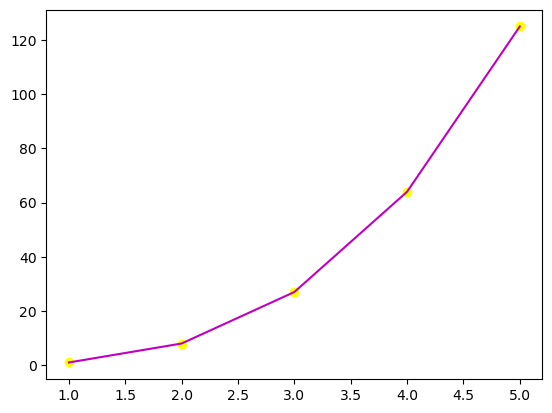

In [60]:
import matplotlib.pyplot as plt
plt.scatter(x,y,color="yellow")
plt.plot(x,y_pred,color="m")
plt.show()